In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Optional (clean output)
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("student-mat.csv", sep=";")
df.head()
print("Shape:",df.shape)
df.info()

Shape: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    objec

In [4]:
df=df.drop(["G1","G2"],axis=1)

In [18]:

# Select Only Important Features

selected_features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "health",
    "goout"
]

X = df[selected_features]
y = df["G3"]


In [19]:
# Encoding 
X_encoded = X.copy()

for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Check data types after encoding
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        395 non-null    int64
 1   studytime  395 non-null    int64
 2   failures   395 non-null    int64
 3   absences   395 non-null    int64
 4   health     395 non-null    int64
 5   goout      395 non-null    int64
dtypes: int64(6)
memory usage: 18.6 KB


In [20]:
# Train Test Split 

X_train,X_test,y_train,y_test= train_test_split(X_encoded,y,test_size=0.2,random_state=42)
print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)


Training Shape: (316, 6)
Testing Shape: (79, 6)


In [10]:
# Linear Model

lr_model= LinearRegression()
lr_model.fit(X_train,y_train)

lr_pred=lr_model.predict(X_test)

In [ ]:
# Evaluation 


print("Linear Regression Performance")

print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print("RMSE:", rmse)


Linear Regression Performance
R2 Score: 0.09565418606292198
MAE: 3.4948497013642124
RMSE: 4.306234278514979


In [21]:
# Random Forest 

rf_model= RandomForestRegressor(n_estimators=300,random_state=42)

rf_model.fit(X_train,y_train)

rf_pred=rf_model.predict(X_test)

In [22]:
# Evaluation 
print("Random Forest Performance")

print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print("RMSE:", rmse)

Random Forest Performance
R2 Score: 0.10999383407718577
MAE: 3.4575615848052563
RMSE: 4.271957221358556


In [23]:
# Feature Importance 

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

feature_importance.head(10)

absences     0.264138
failures     0.163620
health       0.162949
goout        0.154338
age          0.144975
studytime    0.109980
dtype: float64

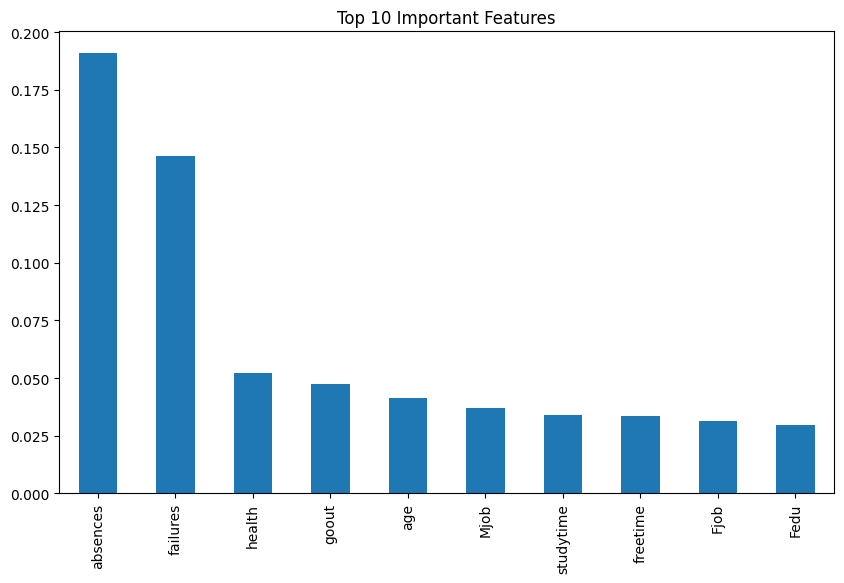

In [16]:
# Feature importance Visual 
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

In [24]:
# Final Model 

import joblib 

joblib.dump(rf_model,"student_performance_model.pkl")
print("Model Saved")


Model Saved
